# Ноутбук 03a: Генерация ответов в controlled-context режиме

**Цель:** прогнать 5 методов RAG × 4 типа шума × 3 уровня шума × 100 вопросов = **6000 ответов**.

## Что делает ноутбук

1. Загружает артефакты из ноутбуков 01-02 (questions, gold_mapping, noise_cache).
2. Реализует **5 методов RAG**: Baseline, Hybrid, Rerank, HyDE, Self-RAG.
3. Реализует функцию `build_controlled_context` для формирования зашумлённого контекста.
4. Прогоняет факторную сетку 5×4×3 = 60 конфигураций × 100 вопросов = 6000 ответов.
5. **Гранулярно кэширует каждый ответ** — после прерывания продолжает с конкретного вопроса, не с конфигурации.
6. **Логирует полностью**: вопрос, контекст (документы по ролям), ответ, время, токены.
7. **Безопасно останавливается при лимитах Groq**: сохраняет кэш и ждёт следующего ручного запуска.

## Архитектура кэша

Один файл на конфигурацию: `answers/controlled/{method}_{noise_type}_{noise_level}.json`.
Внутри — словарь `qid -> {predicted, context_docs, latency, tokens, error}`.
При запуске ноутбука каждая конфигурация подгружает свой файл и пропускает уже обработанные qid.

## Стоимость

- Baseline: 1 LLM-вызов на ответ → 100 × 4 × 3 = 1200 вызовов
- Hybrid: 1 LLM-вызов → 1200
- Rerank: 1 LLM-вызов → 1200
- HyDE: 2 LLM-вызова (гипотеза + ответ) → 2400
- Self-RAG: 2 LLM-вызова (батчевая рефлексия + ответ) → 2400
- **Итого ~8400 вызовов** генератора 70B

## Шаг 0. Установка и инициализация

In [1]:
!pip install -q qdrant-client fastembed groq tqdm tenacity rank-bm25 flashrank pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 27.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import time
import random
import pickle
import re
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

# ---- КОНФИГ ----
QDRANT_URL     = os.environ.get("QDRANT_URL", " ")
QDRANT_API_KEY = os.environ.get("QDRANT_API_KEY", " ")
GROQ_API_KEY   = os.environ.get("GROQ_API_KEY", " ")

SEED = 42
GENERATOR_MODEL = "llama-3.3-70b-versatile"

# Rate limiting (free tier 70B: ~6000 TPM, 500k TPD)
GROQ_TPM_BUDGET     = 5500
GROQ_REQUEST_DELAY  = 0.4

# Параметры RAG
TOP_K_FINAL    = 5    # размер контекста подаваемый в LLM
TOP_K_RETRIEVE = 20   # сколько достаём перед reranking
GENERATOR_MAX_TOKENS = 150

# Сетка эксперимента
METHODS = ["baseline", "query_expansion", "rerank", "hyde", "self_rag"]
NOISE_TYPES  = ["semantic_distractors", "counterfactuals", "duplicates", "structural"]
NOISE_LEVELS = [0, 40, 80]   # проценты шумных документов в контексте

# Embeddings и Qdrant
COLLECTION_CLEAN = "rag_clean"
EMBEDDING_MODEL  = "BAAI/bge-small-en-v1.5"
RERANKER_MODEL   = "ms-marco-MiniLM-L-12-v2"  # из FlashRank, лёгкий и точный

# Пути
ARTIFACTS_DIR = Path("/content/drive/MyDrive/rag_experiment/artifacts")
ANSWERS_DIR   = ARTIFACTS_DIR / "answers" / "controlled"
ANSWERS_DIR.mkdir(parents=True, exist_ok=True)
BM25_CACHE = ARTIFACTS_DIR / "bm25_index.pkl"

random.seed(SEED)
np.random.seed(SEED)

print(f"Generator: {GENERATOR_MODEL}")
print(f"Methods: {METHODS}")
print(f"Noise types: {NOISE_TYPES}")
print(f"Noise levels: {NOISE_LEVELS}")
print(f"Total configs: {len(METHODS)*len(NOISE_TYPES)*len(NOISE_LEVELS)}")
print(f"Answers dir: {ANSWERS_DIR}")

Generator: llama-3.3-70b-versatile
Methods: ['baseline', 'query_expansion', 'rerank', 'hyde', 'self_rag']
Noise types: ['semantic_distractors', 'counterfactuals', 'duplicates', 'structural']
Noise levels: [0, 40, 80]
Total configs: 60
Answers dir: /content/drive/MyDrive/rag_experiment/artifacts/answers/controlled


In [ ]:
import os
import json
import time
import random
import hashlib
import re
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict

import numpy as np
from tqdm.auto import tqdm
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type


SEED = 42

# Модель для генерации шума
GROQ_MODEL = "llama-3.3-70b-versatile"
GROQ_TEMPERATURE = 0.3  # немного вариативности для разнообразия контрафактов

# Rate limiting (Groq free tier: ~6000 TPM для 70B)
# Консервативно ограничимся 5500 TPM чтобы был запас
GROQ_TPM_BUDGET = 5500
GROQ_REQUEST_DELAY = 0.5  # секунд между запросами как базовая задержка

# Параметры генерации шума
N_COUNTERFACTUALS_PER_GOLD = 1  # 1 контрафакт на каждый gold-параграф (итого 2 на вопрос)
N_DUPLICATES_PER_GOLD = 1       # аналогично
MAX_GENERATION_ATTEMPTS = 3     # макс. попыток регенерации если валидация не прошла

# Коллекции в Qdrant
COLLECTION_CLEAN = "rag_clean"
COLLECTION_NOISY = "rag_noisy"
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
EMBEDDING_DIM = 384
CHUNK_SIZE = 512
CHUNK_OVERLAP = 64

# Пути к артефактам
ARTIFACTS_DIR = Path("/content/drive/MyDrive/rag_experiment/artifacts")
assert ARTIFACTS_DIR.exists(), f"Не найдена папка с артефактами: {ARTIFACTS_DIR}"

NOISE_CACHE_PATH = ARTIFACTS_DIR / "noise_cache.json"
NOISE_VALIDATION_REPORT_PATH = ARTIFACTS_DIR / "noise_validation_report.json"

random.seed(SEED)
np.random.seed(SEED)

print(f"Artifacts: {ARTIFACTS_DIR}")
print(f"Groq model: {GROQ_MODEL}")
print(f"Seed: {SEED}")

Artifacts: /content/drive/MyDrive/rag_experiment/artifacts
Groq model: llama-3.3-70b-versatile
Seed: 42


In [5]:
# Загрузка артефактов
with open(ARTIFACTS_DIR / "questions.json", encoding="utf-8") as f:
    questions = json.load(f)
with open(ARTIFACTS_DIR / "gold_mapping.json", encoding="utf-8") as f:
    gold_mapping = json.load(f)
with open(ARTIFACTS_DIR / "noise_cache.json", encoding="utf-8") as f:
    noise_cache = json.load(f)

print(f"Вопросов: {len(questions)}")
print(f"Gold mappings: {len(gold_mapping)}")
print(f"Noise cache: {len(noise_cache)}")

Вопросов: 100
Gold mappings: 100
Noise cache: 100


## Шаг 1. Подключение к сервисам и rate-limited Groq

In [6]:
from qdrant_client import QdrantClient
from fastembed import TextEmbedding
from groq import Groq, RateLimitError, APIError, BadRequestError

qdrant   = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=60)
groq_cli = Groq(api_key=GROQ_API_KEY)
embedder = TextEmbedding(model_name=EMBEDDING_MODEL)

info = qdrant.get_collection(COLLECTION_CLEAN)
print(f"rag_clean: {info.points_count} точек")

# Rate limiter
class GroqTokenBudget:
    def __init__(self, tpm_limit):
        self.tpm_limit = tpm_limit
        self.usage = []
    def _prune(self):
        cutoff = time.time() - 60
        self.usage = [(t, n) for t, n in self.usage if t > cutoff]
    def wait_if_needed(self, est_tokens):
        self._prune()
        used = sum(n for _, n in self.usage)
        if used + est_tokens > self.tpm_limit:
            if self.usage:
                wait_sec = max(0, 60 - (time.time() - self.usage[0][0])) + 1
                time.sleep(wait_sec)
                self._prune()
    def record(self, tokens):
        self.usage.append((time.time(), tokens))

budget = GroqTokenBudget(GROQ_TPM_BUDGET)

class ExperimentLimitReached(RuntimeError):
    """Сигнал для безопасной остановки ноутбука при лимитах/квоте Groq."""


def is_groq_limit_error(exc):
    """True для ошибок, после которых эксперимент надо остановить до следующего ручного запуска."""
    text = str(exc).lower()
    return (
        isinstance(exc, RateLimitError)
        or "rate limit" in text
        or "rate_limit" in text
        or "quota" in text
        or "tokens per day" in text
        or "requests per day" in text
        or "too many requests" in text
        or "429" in text
    )


@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=2, min=4, max=30),
    # ВАЖНО: RateLimitError НЕ ретраим. Если лимит/квота закончились,
    # останавливаем цикл и продолжаем только после следующего ручного запуска.
    retry=retry_if_exception_type(APIError),
    reraise=True,
)
def groq_complete(prompt, max_tokens=GENERATOR_MAX_TOKENS, temperature=0.0, response_format=None):
    """Универсальный вызов Groq с локальным TPM-budget. Лимиты Groq пробрасываются наверх."""
    est = sum(len(prompt) for _ in [1]) // 4 + max_tokens
    budget.wait_if_needed(est)
    kwargs = dict(
        model=GENERATOR_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    if response_format:
        kwargs["response_format"] = response_format
    try:
        resp = groq_cli.chat.completions.create(**kwargs)
    except Exception as e:
        if is_groq_limit_error(e):
            raise ExperimentLimitReached(f"Groq limit/quota reached: {e}") from e
        raise

    actual = resp.usage.total_tokens if resp.usage else est
    budget.record(actual)
    time.sleep(GROQ_REQUEST_DELAY)
    return resp.choices[0].message.content.strip(), actual

# Smoke test
text, tok = groq_complete("Reply with exactly: OK", max_tokens=10)
print(f"Smoke test: '{text}' ({tok} tokens)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

rag_clean: 7997 точек
Smoke test: 'OK' (42 tokens)


## Шаг 2. Утилиты: формирование контекста с шумом

**Логика controlled-context:** при k=5 и уровне шума X% мы берём `X/100*5` шумных документов и `(5 - X/100*5)` gold-related документов. Gold всегда присутствует (иначе вопрос неотвечаем). Порядок документов рандомизируется (детерминировано по seed).

In [7]:
def build_controlled_context(qid, noise_type, noise_level, k=TOP_K_FINAL, seed=SEED):
    """
    Собирает контекст из k документов: gold + (k - n_gold) шумных.

    Возвращает list[dict] с полями: title, text, role.
    role ∈ {gold, semantic_distractors, counterfactuals, duplicates, structural}.

    При noise_level=0 контекст состоит только из gold-документов.
    При noise_level=40 → 2 шумных + 3 gold-related (3 = 2 gold + 1 повтор/distractor).
    При noise_level=80 → 4 шумных + 1 gold.
    """
    rng = random.Random(seed + hash(qid) % 100000 + noise_level)

    n_noise = round(k * noise_level / 100)
    n_clean = k - n_noise

    # Gold документы
    gold_info = gold_mapping[qid]
    gold_docs = [
        {"title": t, "text": gold_info["gold_texts"][t], "role": "gold"}
        for t in gold_info["gold_titles"]
    ]

    # Заполнение clean-слотов: сначала все gold, потом — если нужно ещё — берём дистракторы как нейтральный фон
    clean_docs = list(gold_docs)
    if n_clean > len(gold_docs):
        # дополняем нейтральными дистракторами (разные от выбранного типа шума)
        extra_pool = noise_cache[qid].get("semantic_distractors", [])
        rng.shuffle(extra_pool)
        for d in extra_pool[: n_clean - len(gold_docs)]:
            clean_docs.append({"title": d["title"], "text": d["text"], "role": "background"})
    clean_docs = clean_docs[:n_clean]
    # Если n_clean меньше числа gold (noise_level=80, n_clean=1, gold=2) — берём первый gold

    # Шумные документы выбранного типа
    noise_pool = noise_cache[qid].get(noise_type, [])
    # Для counterfactuals/duplicates берём только validated
    if noise_type in ("counterfactuals", "duplicates"):
        noise_pool = [n for n in noise_pool if n.get("validation_passed", True)]
    rng.shuffle(noise_pool)

    noise_docs = []
    for n in noise_pool[:n_noise]:
        # У разных типов шума разная структура — нормализуем
        text  = n.get("text") or n.get("new_text") or ""
        title = n.get("based_on_title") or n.get("title") or f"noise_{noise_type}"
        noise_docs.append({"title": title, "text": text, "role": noise_type})

    # Если шумного пула не хватает (редко) — добираем из semantic_distractors как fallback
    if len(noise_docs) < n_noise:
        backup = [n for n in noise_cache[qid].get("semantic_distractors", []) if n["title"] not in [d["title"] for d in clean_docs + noise_docs]]
        rng.shuffle(backup)
        for d in backup[: n_noise - len(noise_docs)]:
            noise_docs.append({"title": d["title"], "text": d["text"], "role": "semantic_distractors_fallback"})

    context = clean_docs + noise_docs
    rng.shuffle(context)  # рандомизация порядка чтобы gold не всегда был первым
    return context

# Тест
test_q = questions[0]
for level in NOISE_LEVELS:
    ctx = build_controlled_context(test_q["id"], "counterfactuals", level)
    print(f"\nlevel={level}%, всего {len(ctx)} документов:")
    for c in ctx:
        print(f"  [{c['role']}] {c['title']}: {c['text'][:60]}...")


level=0%, всего 5 документов:
  [background] 2009 New York Jets season: The 2009 New York Jets season was the 50th season for the cl...
  [background] Super Bowl XVIII: Super Bowl XVIII was an American football game between the N...
  [gold] Alan Faneca: Alan Joseph Faneca ( ; born December 7, 1976) is a former pr...
  [gold] Super Bowl XL: Super Bowl XL was an American football game between the Nati...
  [background] Super Bowl XLVIII: Super Bowl XLVIII was an American football game between the ...

level=40%, всего 5 документов:
  [counterfactuals] Super Bowl XL: Super Bowl XL was an American football game between the Nati...
  [background] 2009 New York Jets season: The 2009 New York Jets season was the 50th season for the cl...
  [gold] Alan Faneca: Alan Joseph Faneca ( ; born December 7, 1976) is a former pr...
  [counterfactuals] Alan Faneca: Alan Joseph Faneca ( ; born December 7, 1976) is a former pr...
  [gold] Super Bowl XL: Super Bowl XL was an American football game betwee

## Шаг 3. Промпт RAG и финальная генерация ответа

Один и тот же промпт для всех методов — иначе нельзя сравнивать. Берём проверенный промпт из ноутбука 02b.

In [8]:
RAG_PROMPT = """Answer the question based ONLY on the provided context.
Be concise — give the answer in 1-3 words when possible.
If the context does not contain enough information, respond with: "I don't know".

Context:
{context}

Question: {question}

Answer:"""

def format_context(docs):
    return "\n\n".join(f"[{i+1}] {d['title']}\n{d['text']}" for i, d in enumerate(docs))

def generate_answer(question, context_docs):
    """Финальный шаг любого метода — генерация ответа из готового контекста."""
    prompt = RAG_PROMPT.format(context=format_context(context_docs), question=question)
    answer, tokens = groq_complete(prompt, max_tokens=GENERATOR_MAX_TOKENS)
    return answer, tokens

## Шаг 4. Метод 1 — Baseline

В controlled-context режиме «retrieval» уже сделан вручную через `build_controlled_context`. Baseline просто подаёт этот контекст в LLM.

In [9]:
def method_baseline(question, context_docs):
    """Простейший пайплайн: контекст → LLM."""
    answer, tokens = generate_answer(question, context_docs)
    return {
        "answer": answer,
        "final_context": context_docs,
        "tokens": tokens,
        "extra_calls": 0,
    }

## Шаг 5. Метод 2 — QUERY_EXPANSION



In [10]:
QUERY_EXPANSION_PROMPT = """Generate 3 different phrasings of the following question.
Each phrasing should capture the same intent but use different words or structure.
This helps retrieve relevant documents that might use different terminology.

Original question: {question}

Return a JSON object:
{{
  "expansions": [
    "rephrasing 1",
    "rephrasing 2",
    "rephrasing 3"
  ]
}}"""

def method_query_expansion(question, context_docs):
    """
    Query Expansion: генерируем 3 перефразировки вопроса через LLM,
    для каждой считаем cosine-скоры с документами,
    агрегируем через RRF и переранжируем контекст.

    Тестирует гипотезу: лучшее понимание вопроса помогает
    поставить релевантный документ выше шума.
    """
    # Шаг 1: генерируем перефразировки
    prompt = QUERY_EXPANSION_PROMPT.format(question=question)
    try:
        raw, exp_tokens = groq_complete(
            prompt, max_tokens=200, temperature=0.3,
            response_format={"type": "json_object"}
        )
        data = json.loads(raw)
        expansions = data.get("expansions", [])
        if not expansions:
            raise ValueError("empty expansions")
    except Exception as e:
        # fallback: используем только оригинальный вопрос
        expansions = []
        exp_tokens = 0

    all_queries = [question] + expansions[:3]

    # Шаг 2: для каждой перефразировки считаем cosine-скоры с документами
    doc_texts = [d["text"] for d in context_docs]
    dvecs = list(embedder.embed(doc_texts))

    rankings = []
    for q in all_queries:
        qvec = list(embedder.embed([q]))[0]
        sims = [
            float(np.dot(qvec, dv) / (np.linalg.norm(qvec) * np.linalg.norm(dv)))
            for dv in dvecs
        ]
        order = sorted(range(len(context_docs)), key=lambda i: -sims[i])
        rankings.append(order)

    # Шаг 3: агрегируем через RRF
    fused_order = rrf_rank(rankings)
    reordered = [context_docs[i] for i in fused_order]

    # Шаг 4: финальный ответ
    answer, gen_tokens = generate_answer(question, reordered)

    return {
        "answer": answer,
        "final_context": reordered,
        "expansions": expansions,
        "tokens": exp_tokens + gen_tokens,
        "extra_calls": 1,
    }

## Шаг 6. Метод 3 — Rerank (cross-encoder)

**Идея:** прогоняем 5 документов через cross-encoder reranker, переупорядочиваем по релевантности, оставляем top-5 (то есть все, но в новом порядке). Для controlled-context это означает: LLM увидит наиболее релевантные документы первыми, наименее — последними. Если шум окажется внизу, он оказывает меньше влияния.

In [11]:
from flashrank import Ranker, RerankRequest

print("Загружаю reranker (FlashRank, CPU)...")
reranker = Ranker(model_name=RERANKER_MODEL, cache_dir="/tmp/flashrank")
print("Reranker готов")

def method_rerank(question, context_docs):
    """Cross-encoder переранжирование."""
    passages = [{"id": i, "text": d["text"], "meta": {"title": d["title"], "role": d["role"]}}
                for i, d in enumerate(context_docs)]
    req = RerankRequest(query=question, passages=passages)
    ranked = reranker.rerank(req)  # отсортировано по убыванию релевантности

    reordered = [context_docs[r["id"]] for r in ranked]
    answer, tokens = generate_answer(question, reordered)
    return {
        "answer": answer,
        "final_context": reordered,
        "rerank_scores": [float(r["score"]) for r in ranked],
        "tokens": tokens,
        "extra_calls": 0,
    }

Загружаю reranker (FlashRank, CPU)...



ms-marco-MiniLM-L-12-v2.zip:   0%|          | 0.00/21.6M [00:00<?, ?iB/s]
ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:00<00:00, 152MiB/s]


Reranker готов


## Шаг 7. Метод 4 — HyDE (Hypothetical Document Embeddings)

**Идея HyDE из оригинальной статьи Gao et al. 2022:**
1. Просим LLM сгенерировать гипотетический ответ-параграф на вопрос (без контекста).
2. Эмбеддим эту гипотезу.
3. Считаем cosine similarity гипотезы с каждым из 5 документов контекста и переранжируем.

**Зачем:** гипотетический ответ ближе по стилю к реальному документу с ответом, чем сам вопрос. Это особенно помогает против семантических дистракторов.

In [12]:
HYDE_PROMPT = """Write a short, factual paragraph that would answer the following question.
Write as if it were an excerpt from an encyclopedia article — confident and specific.
If you don't know the answer, write a plausible-sounding paragraph anyway.

Question: {question}

Paragraph:"""

def method_hyde(question, context_docs):
    """HyDE: генерим гипотезу, эмбеддим, переранжируем контекст по близости к гипотезе."""
    # Шаг 1: гипотеза
    hyp_prompt = HYDE_PROMPT.format(question=question)
    hypothesis, hyp_tokens = groq_complete(hyp_prompt, max_tokens=200, temperature=0.0)

    # Шаг 2: эмбеддинг гипотезы и документов
    hvec = list(embedder.embed([hypothesis]))[0]
    dvecs = list(embedder.embed([d["text"] for d in context_docs]))

    sims = [float(np.dot(hvec, dv) / (np.linalg.norm(hvec)*np.linalg.norm(dv))) for dv in dvecs]
    order = sorted(range(len(context_docs)), key=lambda i: -sims[i])
    reordered = [context_docs[i] for i in order]

    # Шаг 3: финальный ответ
    answer, tokens = generate_answer(question, reordered)
    return {
        "answer": answer,
        "final_context": reordered,
        "hypothesis": hypothesis,
        "sims": sims,
        "tokens": tokens + hyp_tokens,
        "extra_calls": 1,
    }

MethMEMe<<<<<MMMbbbbbbcbcbbbffwsfffff## Шаг 8. Метод 5 — Self-RAG (батчевая рефлексия)

**Идея Self-RAG:** перед генерацией ответа модель сама оценивает релевантность каждого документа в контексте, и из дальнейшего рассуждения исключаются нерелевантные. Это защита от шума через **рефлексию агента**.

**Батчевая версия:** один промпт со всеми 5 документами, модель возвращает JSON со скорами 0-1 для каждого. Это в 5 раз дешевле чем per-document версия.

Если все документы признаны нерелевантными — отвечаем «I don't know» (это и есть Negative Rejection).

In [13]:
from collections import defaultdict

def rrf_rank(rankings_lists, k_rrf=60):
    """Reciprocal Rank Fusion. rankings_lists — list of list of doc indices."""
    scores = defaultdict(float)
    for ranking in rankings_lists:
        for rank, doc_id in enumerate(ranking):
            scores[doc_id] += 1.0 / (k_rrf + rank + 1)
    return sorted(scores.keys(), key=lambda x: -scores[x])
RELEVANCE_PROMPT = """You are evaluating the relevance of retrieved documents to a question.

Question: {question}

Documents:
{docs}

For each document, decide if it contains information that helps answer the question.

Return a JSON object:
{{
  "relevance": [
    {{"doc_id": 1, "relevant": true or false, "reason": "short explanation"}},
    ...
  ]
}}

A document is RELEVANT if it directly contains facts needed to answer the question.
A document is NOT RELEVANT if it is about a different topic, or contains contradictory/incorrect information that doesn't match the question's premise."""

RELEVANCE_THRESHOLD = 0.5  # для будущих версий со скорами

def method_self_rag(question, context_docs):
    """Self-RAG с батчевой рефлексией: фильтруем нерелевантные, потом отвечаем."""
    docs_str = "\n\n".join(f"[Document {i+1}] {d['title']}\n{d['text']}"
                            for i, d in enumerate(context_docs))

    rel_prompt = RELEVANCE_PROMPT.format(question=question, docs=docs_str)

    try:
        rel_response, rel_tokens = groq_complete(
            rel_prompt, max_tokens=400, temperature=0.0,
            response_format={"type": "json_object"}
        )
        rel_data = json.loads(rel_response)
        relevance = rel_data.get("relevance", [])
        # docs_id здесь 1-индексированы
        relevant_ids = {r["doc_id"] - 1 for r in relevance if r.get("relevant")}
        reflection_log = relevance
    except (json.JSONDecodeError, KeyError, BadRequestError) as e:
        # fallback: оставляем все документы
        relevant_ids = set(range(len(context_docs)))
        reflection_log = [{"error": str(e)[:100]}]
        rel_tokens = 0

    filtered = [d for i, d in enumerate(context_docs) if i in relevant_ids]

    if not filtered:
        # все отфильтровали — отвечаем negative rejection
        return {
            "answer": "I don't know",
            "final_context": [],
            "reflection_log": reflection_log,
            "tokens": rel_tokens,
            "extra_calls": 1,
        }

    answer, tokens = generate_answer(question, filtered)
    return {
        "answer": answer,
        "final_context": filtered,
        "reflection_log": reflection_log,
        "tokens": tokens + rel_tokens,
        "extra_calls": 1,
    }

## Шаг 9. Smoke test всех методов на одном вопросе

Прежде чем запускать массовую генерацию — проверяем что каждый метод работает.

In [14]:
METHOD_REGISTRY = {
    "baseline":         method_baseline,
    "query_expansion":  method_query_expansion,
    "rerank":           method_rerank,
    "hyde":             method_hyde,
    "self_rag":         method_self_rag,
}

test_q = questions[0]
test_ctx = build_controlled_context(test_q["id"], "counterfactuals", 40)

print(f"Тестовый вопрос: {test_q['question']}")
print(f"Эталон: {test_q['answer']}")
print(f"Контекст: {len(test_ctx)} документов с ролями {[d['role'] for d in test_ctx]}\n")

for name, fn in METHOD_REGISTRY.items():
    print(f"--- {name} ---")
    try:
        result = fn(test_q["question"], test_ctx)
        print(f"  Answer: {result['answer']}")
        print(f"  Final ctx roles: {[d['role'] for d in result['final_context']]}")
        if "hypothesis" in result:
            print(f"  Hypothesis: {result['hypothesis'][:100]}...")
        if "reflection_log" in result and isinstance(result['reflection_log'], list):
            kept = sum(1 for r in result['reflection_log'] if r.get('relevant'))
            print(f"  Self-RAG kept: {kept}/{len(test_ctx)}")
        print(f"  Tokens: {result['tokens']}")
    except Exception as e:
        print(f"  ERROR: {e}")
    print()

Тестовый вопрос: Where was the Super Bowl, that Alan Faneca won, played ?
Эталон: Ford Field in Detroit
Контекст: 5 документов с ролями ['counterfactuals', 'background', 'gold', 'counterfactuals', 'gold']

--- baseline ---
  Answer: Lambeau Field
  Final ctx roles: ['counterfactuals', 'background', 'gold', 'counterfactuals', 'gold']
  Tokens: 747

--- query_expansion ---
  Answer: Lambeau Field
  Final ctx roles: ['counterfactuals', 'gold', 'background', 'counterfactuals', 'gold']
  Tokens: 955

--- rerank ---
  Answer: Lambeau Field
  Final ctx roles: ['counterfactuals', 'gold', 'background', 'gold', 'counterfactuals']
  Tokens: 747

--- hyde ---
  Answer: Lambeau Field
  Final ctx roles: ['counterfactuals', 'gold', 'counterfactuals', 'gold', 'background']
  Hypothesis: The Super Bowl in which Alan Faneca emerged victorious was Super Bowl XLIII, played on February 1, 2...
  Tokens: 957

--- self_rag ---
  Answer: Detroit
  Final ctx roles: ['gold']
  Self-RAG kept: 1/5
  Tokens: 1217


## Шаг 10. Гранулярное кэширование и основной цикл

**Ключевая логика:**
- Один файл на конфигурацию: `controlled/{method}_{noise_type}_{noise_level}.json`.
- При запуске каждой конфигурации: подгружаем существующий файл, видим какие qid уже есть, обрабатываем только пропущенные.
- После каждого нового ответа — записываем файл целиком (атомарно через временный файл).
- Можно прервать в любой момент Ctrl+C — состояние на диске согласовано.

Для оптимизации последовательность конфигураций важна: внешний цикл по типам шума → чтобы можно было досрочно посмотреть результаты по одному типу шума целиком.

In [15]:
def config_path(method, noise_type, noise_level):
    return ANSWERS_DIR / f"{method}__{noise_type}__lvl{noise_level}.json"

def load_config_cache(method, noise_type, noise_level):
    p = config_path(method, noise_type, noise_level)
    if p.exists():
        with open(p, encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_config_cache(method, noise_type, noise_level, cache):
    p = config_path(method, noise_type, noise_level)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    tmp.replace(p)

def serialize_context(docs):
    """Уменьшаем контекст для кэша — храним только title, role и обрезанный текст."""
    return [{"title": d["title"], "role": d["role"], "text": d["text"]} for d in docs]

def run_one(method_name, noise_type, noise_level, q):
    """Полный прогон одного вопроса для одной конфигурации."""
    qid = q["id"]
    ctx = build_controlled_context(qid, noise_type, noise_level)

    t0 = time.time()
    fn = METHOD_REGISTRY[method_name]

    try:
        result = fn(q["question"], ctx)
        record = {
            "qid":             qid,
            "question":        q["question"],
            "gold":            q["answer"],
            "predicted":       result["answer"],
            "input_context":   serialize_context(ctx),
            "final_context":   serialize_context(result["final_context"]),
            "latency_sec":     round(time.time() - t0, 2),
            "tokens":          result["tokens"],
            "hypothesis":      result.get("hypothesis"),
            "reflection_log":  result.get("reflection_log"),
            "rerank_scores":   result.get("rerank_scores"),
            "error":           None,
        }
    except ExperimentLimitReached:
        # Лимиты/квота Groq — не записываем как ошибку конкретного вопроса,
        # а прерываем весь прогон. Уже готовые ответы сохранены в кэше.
        raise
    except Exception as e:
        record = {
            "qid":           qid,
            "question":      q["question"],
            "gold":          q["answer"],
            "predicted":     None,
            "input_context": serialize_context(ctx),
            "latency_sec":   round(time.time() - t0, 2),
            "error":         f"{type(e).__name__}: {str(e)[:300]}",
        }
    return record

def run_config(method, noise_type, noise_level, verbose=True):
    """Прогоняет одну конфигурацию по всем 100 вопросам с инкрементальным кэшированием."""
    cache = load_config_cache(method, noise_type, noise_level)
    pending = [q for q in questions if q["id"] not in cache]

    desc = f"{method}/{noise_type}/lvl{noise_level}"
    if not pending:
        if verbose:
            print(f"  [{desc}] уже готово: {len(cache)}/100")
        return cache

    if verbose:
        print(f"  [{desc}] обработано {len(cache)}/100, осталось {len(pending)}")

    for q in tqdm(pending, desc=desc, leave=False):
        try:
            record = run_one(method, noise_type, noise_level, q)
        except ExperimentLimitReached as e:
            save_config_cache(method, noise_type, noise_level, cache)
            print("\n⛔ Groq limit/quota reached. Прогон остановлен безопасно.")
            print(f"   Конфигурация: {desc}")
            print(f"   Уже сохранено в этой конфигурации: {len(cache)}/100")
            print("   Перезапустите эту ячейку позже: готовые qid будут пропущены по кэшу.")
            raise SystemExit(str(e))

        cache[q["id"]] = record
        save_config_cache(method, noise_type, noise_level, cache)

        if verbose:
            tqdm.write(f"\n[QID: {q['id']}]")
            tqdm.write(f"Q: {record.get('question')}")
            tqdm.write(f"Gold: {record.get('gold')}")

            if record.get("error"):
                tqdm.write(f"ERROR: {record['error']}")
            else:
                tqdm.write(f"A: {record.get('predicted')}")

            tqdm.write("-" * 80)

    return cache

In [16]:
# Сводка перед запуском
configs = list(product(METHODS, NOISE_TYPES, NOISE_LEVELS))
print(f"Всего конфигураций: {len(configs)}")

done = 0
for m, nt, nl in configs:
    cache = load_config_cache(m, nt, nl)
    done += len(cache)
total_answers = len(configs) * len(questions)
print(f"Уже обработано ответов: {done} / {total_answers} ({100*done/total_answers:.1f}%)")

Всего конфигураций: 60
Уже обработано ответов: 6000 / 6000 (100.0%)


## Шаг 11. Запуск массовой генерации

Идём по конфигурациям в детерминированном порядке: сначала по типам шума (выводы по типу можно получать раньше), потом по методам, потом по уровням шума.

In [17]:
# # Порядок: noise_type → method → noise_level
# for noise_type in NOISE_TYPES:
#     print(f"\n{'=' * 70}")
#     print(f"NOISE TYPE: {noise_type}")
#     print("=" * 70)
#     for method in METHODS:
#         for noise_level in NOISE_LEVELS:
#             run_config(method, noise_type, noise_level)
#     print(f"\nЗакончили noise_type={noise_type}")

In [18]:
import json

def config_path(method, noise_type, noise_level):
    return ANSWERS_DIR / f"{method}__{noise_type}__lvl{noise_level}.json"

for method in METHODS:
    for noise_type in NOISE_TYPES:
        for noise_level in NOISE_LEVELS:
            path = config_path(method, noise_type, noise_level)
            if not path.exists():
                continue

            with open(path, "r", encoding="utf-8") as f:
                cache = json.load(f)

            bad = [rec for rec in cache.values() if rec.get("error")]
            if bad:
                print(f"\n=== {method} | {noise_type} | lvl={noise_level} ===")
                for rec in bad[:10]:
                    print(f"QID: {rec.get('qid')}")
                    print(f"Q: {rec.get('question')}")
                    print(f"ERROR: {rec.get('error')}")
                    print("-" * 80)

In [19]:
import json

# Порядок: noise_type → method → noise_level
for noise_type in NOISE_TYPES:
    print(f"\n{'=' * 70}")
    print(f"NOISE TYPE: {noise_type}")
    print("=" * 70)

    for method in METHODS:
        for noise_level in NOISE_LEVELS:
            run_config(method, noise_type, noise_level)

            result_path = ANSWERS_DIR / f"{method}__{noise_type}__lvl{noise_level}.json"

            if result_path.exists():
                with open(result_path, "r", encoding="utf-8") as f:
                    data = json.load(f)

                for qid, item in data.items():
                    print(f"\n[QID: {qid}]")
                    print(f"Q: {item.get('question')}")
                    print(f"Gold: {item.get('gold')}")
                    if item.get("error"):
                        print(f"ERROR: {item.get('error')}")
                    else:
                        print(f"A: {item.get('predicted')}")
                    print("-" * 50)

    print(f"\nЗакончили noise_type={noise_type}")

Выходные данные были обрезаны до нескольких последних строк (5000).
Q: Which magazine had more previous names, Watercolor Artist or The General?
Gold: The General
A: The General
--------------------------------------------------

[QID: 5a735c3a55429901807daff7]
Q: Nikolay Mitrofanovich Krylov and Anatoly Fomenko both held what academic title?
Gold: mathematician
A: Professor
--------------------------------------------------

[QID: 5a762cf0554299109176e6a4]
Q: Who is older, Bertalan Farkas or Hans Schlegel?
Gold: Bertalan Farkas
A: Bertalan Farkas
--------------------------------------------------

[QID: 5a711cb45542994082a3e59f]
Q: Who has won more Grand Slam women's doubles titles, Lisa Raymond or Liezel Huber?
Gold: Liezel Huber
A: Lisa Raymond
--------------------------------------------------

[QID: 5a8b544855429950cd6afcae]
Q: Which animated film was released first, The Country Bears or The Wild?
Gold: The Country Bears
A: The Country Bears
---------------------------------------

In [20]:
import json
import random

def config_path(method, noise_type, noise_level):
    return ANSWERS_DIR / f"{method}__{noise_type}__lvl{noise_level}.json"

all_records = []

for method in METHODS:
    for noise_type in NOISE_TYPES:
        for noise_level in NOISE_LEVELS:
            path = config_path(method, noise_type, noise_level)

            if not path.exists():
                continue

            with open(path, "r", encoding="utf-8") as f:
                cache = json.load(f)

            for qid, rec in cache.items():
                all_records.append({
                    "qid": qid,
                    "method": method,
                    "noise_type": noise_type,
                    "noise_level": noise_level,
                    "question": rec.get("question"),
                    "predicted": rec.get("predicted"),
                    "error": rec.get("error"),
                })

print(f"Всего найдено записей: {len(all_records)}")

sample_size = min(5, len(all_records))
sample = random.sample(all_records, sample_size)

for i, rec in enumerate(sample, 1):
    print("=" * 100)
    print(f"[{i}] qid={rec['qid']} | method={rec['method']} | noise={rec['noise_type']} | lvl={rec['noise_level']}")
    print(f"Q: {rec['question']}")
    if rec["error"] is not None:
        print(f"ERROR: {rec['error']}")
    else:
        print(f"A: {rec['predicted']}")

Всего найдено записей: 6000
[1] qid=5a88016b5542997e5c09a58a | method=self_rag | noise=counterfactuals | lvl=40
Q: Migene González-Wippler is leading expert on a religion that developed among which ethnic group ?
A: West African
[2] qid=5a8b20b85542996c9b8d5fb5 | method=baseline | noise=structural | lvl=0
Q: Who was the  "King of Denmark, the Vends and the Goths, elected King of Norway's" brother?
A: John
[3] qid=5a8468c95542990548d0b2b1 | method=baseline | noise=semantic_distractors | lvl=80
Q: What British publisher published a dystopian novel in 1949 written by an English author?
A: Fredric Warburg
[4] qid=5a7bc1bf55429927d897c033 | method=query_expansion | noise=structural | lvl=40
Q: Which breed was bred first, the English Water Spaniel or the Estonian Hound?
A: English Water Spaniel
[5] qid=5a8466a75542993344746108 | method=query_expansion | noise=duplicates | lvl=80
Q: What is the name of the so-called reform opera for Vienna that came before the one first performed in Vienna in

## Шаг 12. Вывод всех ответов с подробностями

Большой подробный лог: показываем все полученные ответы вместе с контекстом и ролями документов. Это позволяет ручную верификацию того, что эксперимент работает корректно.

In [21]:
# Сводная таблица всех конфигураций
rows = []
for method, noise_type, noise_level in configs:
    cache = load_config_cache(method, noise_type, noise_level)
    completed = sum(1 for v in cache.values() if v.get("error") is None)
    errors = sum(1 for v in cache.values() if v.get("error"))
    rows.append({
        "method":      method,
        "noise_type":  noise_type,
        "noise_level": noise_level,
        "completed":   completed,
        "errors":      errors,
        "file":        config_path(method, noise_type, noise_level).name,
    })

df = pd.DataFrame(rows)
print("Сводка по всем конфигурациям:")
print(df.to_string(index=False))

Сводка по всем конфигурациям:
         method           noise_type  noise_level  completed  errors                                              file
       baseline semantic_distractors            0        100       0         baseline__semantic_distractors__lvl0.json
       baseline semantic_distractors           40        100       0        baseline__semantic_distractors__lvl40.json
       baseline semantic_distractors           80        100       0        baseline__semantic_distractors__lvl80.json
       baseline      counterfactuals            0        100       0              baseline__counterfactuals__lvl0.json
       baseline      counterfactuals           40        100       0             baseline__counterfactuals__lvl40.json
       baseline      counterfactuals           80        100       0             baseline__counterfactuals__lvl80.json
       baseline           duplicates            0        100       0                   baseline__duplicates__lvl0.json
       baseline   

In [22]:
# Подробный вывод первых 5 ответов из каждой конфигурации
PREVIEW_N = 5

for method in METHODS:
    for noise_type in NOISE_TYPES:
        for noise_level in NOISE_LEVELS:
            cache = load_config_cache(method, noise_type, noise_level)
            if not cache:
                continue
            print(f"\n{'=' * 70}")
            print(f"  {method} | {noise_type} | level={noise_level}%")
            print("=" * 70)

            shown = 0
            for qid, rec in list(cache.items())[:PREVIEW_N]:
                shown += 1
                print(f"\n[{shown}] Q: {rec['question'][:80]}")
                print(f"     Gold:      {rec['gold']}")
                if rec.get("error"):
                    print(f"     ERROR:     {rec['error']}")
                else:
                    print(f"     Predicted: {rec['predicted']}")
                    roles_in = Counter(d["role"] for d in rec["input_context"])
                    roles_out = Counter(d["role"] for d in rec["final_context"])
                    print(f"     Input roles:  {dict(roles_in)}")
                    print(f"     Final roles:  {dict(roles_out)}")
                    if rec.get("hypothesis"):
                        print(f"     Hypothesis: {rec['hypothesis'][:120]}...")
                    if rec.get("reflection_log") and isinstance(rec["reflection_log"], list):
                        kept = sum(1 for r in rec["reflection_log"] if r.get("relevant"))
                        total = len(rec["reflection_log"])
                        print(f"     Self-RAG: kept {kept}/{total}")
                    print(f"     Latency:   {rec['latency_sec']}s, tokens: {rec.get('tokens', '?')}")


  baseline | semantic_distractors | level=0%

[1] Q: Where was the Super Bowl, that Alan Faneca won, played ?
     Gold:      Ford Field in Detroit
     Predicted: Detroit
     Input roles:  {'gold': 2, 'background': 3}
     Final roles:  {'gold': 2, 'background': 3}
     Latency:   52.18s, tokens: 907

[2] Q: National Firearms Agreement was in response to the Port Arthur massacre that kil
     Gold:      35 people
     Predicted: 35 people
     Input roles:  {'gold': 2, 'background': 3}
     Final roles:  {'gold': 2, 'background': 3}
     Latency:   0.6s, tokens: 683

[3] Q: in 1999, Spirit Halloween LLC was purchased by a mall retailer that has how many
     Gold:      over 600 stores
     Predicted: Over 600
     Input roles:  {'gold': 2, 'background': 3}
     Final roles:  {'gold': 2, 'background': 3}
     Latency:   2.27s, tokens: 900

[4] Q: What other method of extending an ice hockey game exists other than the one used
     Gold:      the shootout
     Predicted: Shootout
    

## Шаг 13. Быстрая статистика

Простейшая EM/F1 прямо здесь — без полноценной оценки (она будет в ноутбуке 03c через LLM-judge), но для понимания тренда полезно увидеть сразу.

In [23]:
import string as _string

def normalize(s):
    if not s: return ""
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(c for c in s if c not in _string.punctuation)
    return ' '.join(s.split())

def f1(pred, gold):
    pt = normalize(pred).split()
    gt = normalize(gold).split()
    if not pt or not gt: return 0.0
    common = sum((Counter(pt) & Counter(gt)).values())
    if common == 0: return 0.0
    p = common / len(pt); r = common / len(gt)
    return 2*p*r/(p+r)

stats = []
for method, noise_type, noise_level in configs:
    cache = load_config_cache(method, noise_type, noise_level)
    if not cache: continue
    em_list, f1_list = [], []
    for rec in cache.values():
        if rec.get("error") or rec.get("predicted") is None: continue
        em_list.append(int(normalize(rec["predicted"]) == normalize(rec["gold"])))
        f1_list.append(f1(rec["predicted"], rec["gold"]))
    if em_list:
        stats.append({
            "method":      method,
            "noise_type":  noise_type,
            "noise_level": noise_level,
            "n":           len(em_list),
            "EM":          round(sum(em_list)/len(em_list), 3),
            "F1":          round(sum(f1_list)/len(f1_list), 3),
        })

stats_df = pd.DataFrame(stats)
print("Быстрая статистика (EM/F1):")
print(stats_df.to_string(index=False))

# Сохраняем для следующих ноутбуков
stats_df.to_csv(ARTIFACTS_DIR / "03a_quick_stats.csv", index=False)
print(f"\nСохранено в {ARTIFACTS_DIR / '03a_quick_stats.csv'}")

Быстрая статистика (EM/F1):
         method           noise_type  noise_level   n   EM    F1
       baseline semantic_distractors            0 100 0.50 0.718
       baseline semantic_distractors           40 100 0.47 0.688
       baseline semantic_distractors           80 100 0.22 0.316
       baseline      counterfactuals            0 100 0.47 0.678
       baseline      counterfactuals           40 100 0.40 0.582
       baseline      counterfactuals           80 100 0.31 0.463
       baseline           duplicates            0 100 0.48 0.687
       baseline           duplicates           40 100 0.50 0.700
       baseline           duplicates           80 100 0.47 0.689
       baseline           structural            0 100 0.48 0.704
       baseline           structural           40 100 0.47 0.703
       baseline           structural           80 100 0.36 0.513
query_expansion semantic_distractors            0 100 0.49 0.709
query_expansion semantic_distractors           40 100 0.50 0.6

In [24]:
# Сводный обзор: средняя F1 по методам и уровням шума
if stats:
    pivot = stats_df.pivot_table(
        values="F1",
        index=["method", "noise_type"],
        columns="noise_level",
    )
    print("\nF1 по методам × тип шума × уровень:")
    print(pivot.round(3).to_string())


F1 по методам × тип шума × уровень:
noise_level                              0      40     80
method          noise_type                               
baseline        counterfactuals       0.678  0.582  0.463
                duplicates            0.687  0.700  0.689
                semantic_distractors  0.718  0.688  0.316
                structural            0.704  0.703  0.513
hyde            counterfactuals       0.697  0.587  0.489
                duplicates            0.688  0.688  0.656
                semantic_distractors  0.698  0.694  0.305
                structural            0.702  0.707  0.554
query_expansion counterfactuals       0.715  0.549  0.494
                duplicates            0.726  0.697  0.705
                semantic_distractors  0.709  0.698  0.322
                structural            0.699  0.709  0.537
rerank          counterfactuals       0.708  0.528  0.515
                duplicates            0.710  0.699  0.657
                semantic_distractor

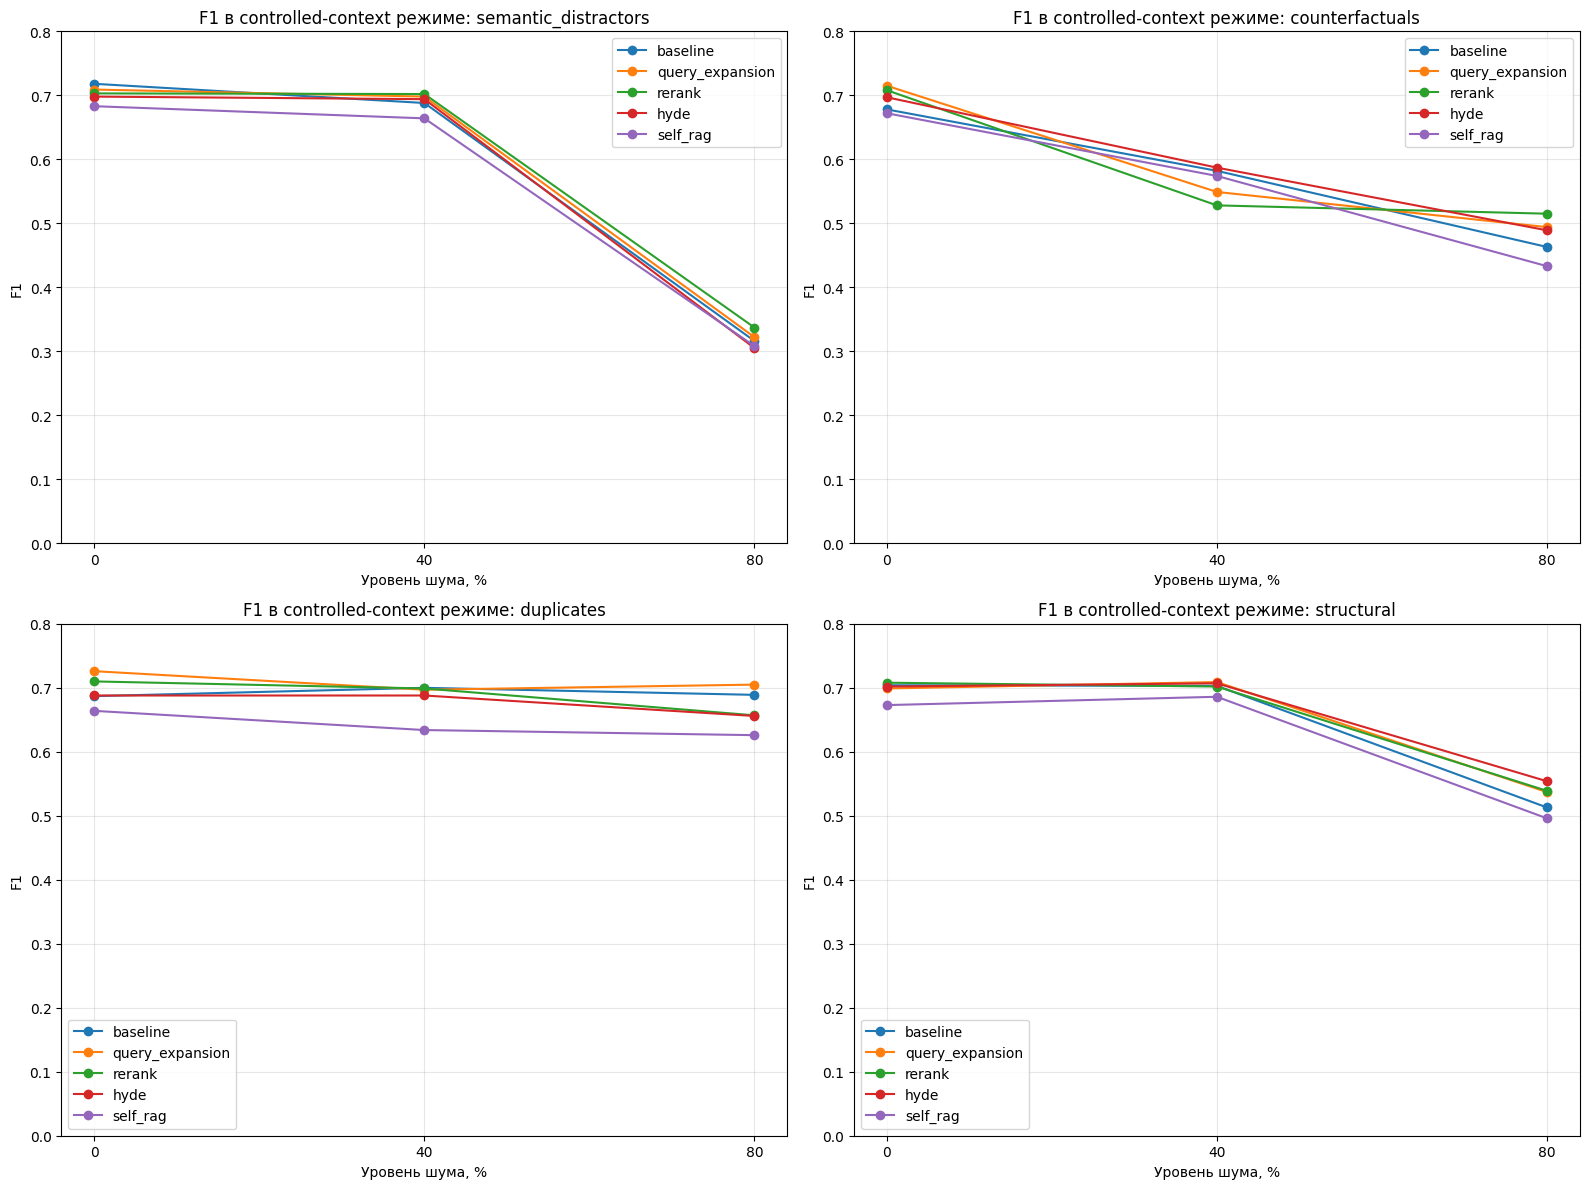

In [29]:
import matplotlib.pyplot as plt

# если stats_df уже создан в шаге 13, этот блок сразу сработает
plot_df = stats_df.copy()

noise_types = plot_df["noise_type"].unique()

# Determine the number of rows and columns for subplots
num_noise_types = len(noise_types)
num_cols = 2
num_rows = (num_noise_types + num_cols - 1) // num_cols # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(8 * num_cols, 6 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, noise_type in enumerate(noise_types):
    subset = plot_df[plot_df["noise_type"] == noise_type]

    ax = axes[i]

    for method in subset["method"].unique():
        method_df = subset[subset["method"] == method].sort_values("noise_level")
        ax.plot(
            method_df["noise_level"],
            method_df["F1"],
            marker="o",
            label=method
        )

    ax.set_title(f"F1 в controlled-context режиме: {noise_type}")
    ax.set_xlabel("Уровень шума, %")
    ax.set_ylabel("F1")
    ax.set_xticks([0, 40, 80])
    ax.set_ylim(0, 0.8)
    ax.grid(True, alpha=0.3)
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


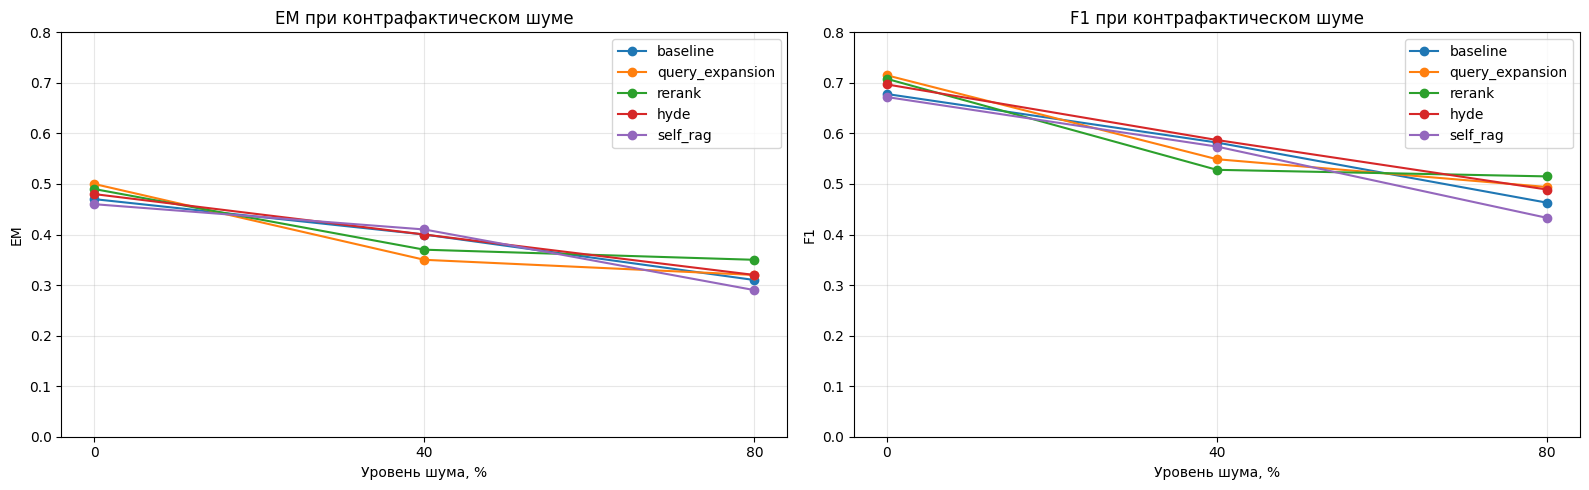

In [31]:
import matplotlib.pyplot as plt

cf_df = stats_df[stats_df["noise_type"] == "counterfactuals"].copy()

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 5)) # Adjust figsize as needed

for i, metric in enumerate(["EM", "F1"]):
    ax = axes[i] # Get the current subplot axis

    for method in cf_df["method"].unique():
        method_df = cf_df[cf_df["method"] == method].sort_values("noise_level")
        ax.plot(
            method_df["noise_level"],
            method_df[metric],
            marker="o",
            label=method
        )

    ax.set_title(f"{metric} при контрафактическом шуме")
    ax.set_xlabel("Уровень шума, %")
    ax.set_ylabel(metric)
    ax.set_xticks([0, 40, 80])
    ax.set_ylim(0, 0.8)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


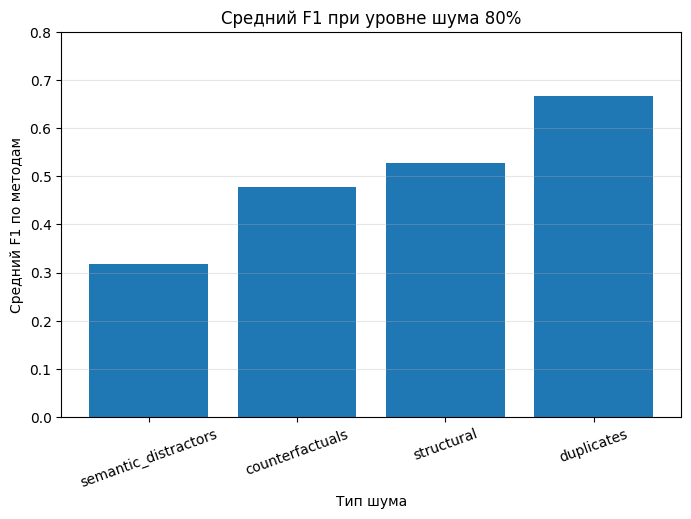

In [32]:
import matplotlib.pyplot as plt

lvl80 = stats_df[stats_df["noise_level"] == 80].copy()

avg_lvl80 = (
    lvl80
    .groupby("noise_type", as_index=False)["F1"]
    .mean()
    .sort_values("F1")
)

plt.figure(figsize=(8, 5))
plt.bar(avg_lvl80["noise_type"], avg_lvl80["F1"])

plt.title("Средний F1 при уровне шума 80%")
plt.xlabel("Тип шума")
plt.ylabel("Средний F1 по методам")
plt.ylim(0, 0.8)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.show()